#Discrete-time quantum walk

The discrete-time quantum walk is defined by the coupled recurrence equations for the complex amplitudes  ($A$, $B$). At each time step $t$, a local coin rotation by angle $\theta$ is immediately followed by a chiral spatial shift:
\begin{align}
    A(x, t+1) &= \cos\theta \, A(x+1, t) + \sin\theta \, B(x+1, t), \\
    B(x, t+1) &= \sin\theta \, A(x-1, t) - \cos\theta \, B(x-1, t).
\end{align}

The system is initialized at the origin $x=0$ at $t=0$ with amplitudes $A(0,0) = A_0$ and $B(0,0) = B_0$, satisfying $|A_0|^2 + |B_0|^2 = 1$. The observable probability distribution evaluated at any time $t$ is strictly given by:
\begin{equation}
    P(x,t) = |A(x,t)|^2 + |B(x,t)|^2.
\end{equation}

Because the evolution operator is strictly unitary, the total probability is conserved:
\begin{equation}
    \sum_{x} P(x,t) = 1 \quad \forall t.
\end{equation}

To better observe the QW spreading the implementation defines a scaled probability at each time step:
\begin{equation}
    \mathcal{P}(x,t) = \frac{P(x,t)}{\max_{x'} P(x',t)}.
\end{equation}



Normalization OK within 0.1% tolerance


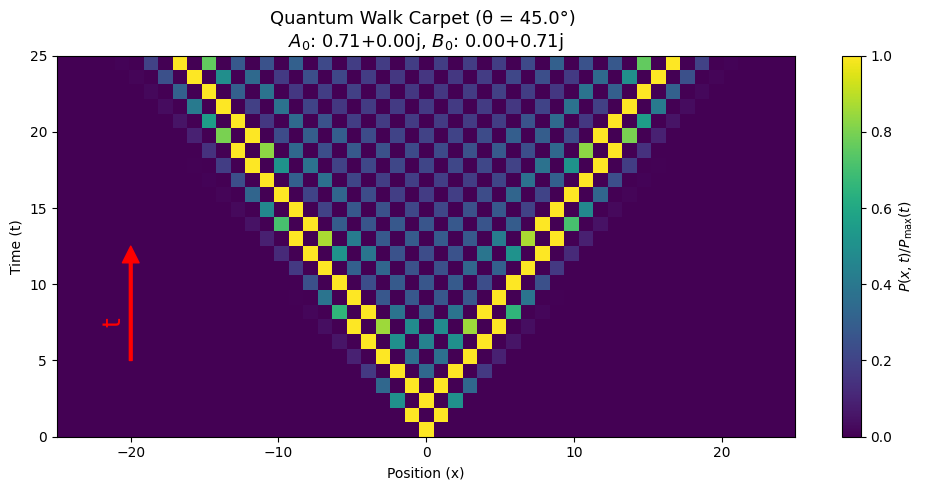

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
t_max = 25                     # number of time steps
theta_deg = 45 ; theta = np.radians(theta_deg)         # coin angle in radians
Ao_r = 0.70710678              # real part of A0 (example: 1/√2)
Ao_c = 0.0                     # imag part of A0
Bo_r = 0.0                     # real part of B0
Bo_c = 0.70710678              # imag part of B0 (example: i/√2)

theme = "bright"               # "bright" or "dark"

# --- GRID ---
n = 2*t_max + 1
mid = t_max
x = np.arange(-t_max, t_max+1)

# --- INITIAL STATE ---
A = np.zeros(n, dtype=complex)
B = np.zeros(n, dtype=complex)

A[mid] = Ao_r + 1j*Ao_c
B[mid] = Bo_r + 1j*Bo_c

# Verify normalization of the initial state
norm0 = abs(A[mid])**2 + abs(B[mid])**2
if abs(norm0 - 1.0) > 1e-15:
    print(f"Warning: |A0|² + |B0|² = {norm0:.16f} (should be ~1)")

# --- COIN ---
c, s = np.cos(theta), np.sin(theta)

# --- STORAGE ---
carpet = np.zeros((t_max+1, n))

# --- EVOLUTION & NORMALIZATION CHECK ---
for t in range(t_max+1):

    P = np.abs(A)**2 + np.abs(B)**2
    total = np.sum(P)

    # --- Normalization check (0.1% tolerance) ---
    if abs(total - 1.0) > 1e-3:
        print(f"WARNING: Not normalized at t={t} | Total = {total:.6f}")
    else:
        if t == 0:
            print("Normalization OK within 0.1% tolerance")

    # --- Normalize for visualization (P(x,t) / Pmax(t)) ---
    Pmax = np.max(P)
    if Pmax > 0:
        carpet[t, :] = P / Pmax

    # --- Evolution step ---
    A_new = c*A + s*B
    B_new = s*A - c*B

    A = np.roll(A_new, -1)
    B = np.roll(B_new,  1)

# --- VISUAL STYLE ---
if theme == "dark":
    cmap = "magma"
    arrow_color = "white"
    text_color = "white"
elif theme == "bright":
    cmap = "viridis"
    arrow_color = "red"
    text_color = "red"
else:
    raise ValueError("theme must be 'dark' or 'bright'")

# --- PLOT ---
plt.figure(figsize=(10,5))
im = plt.imshow(carpet, extent=[-t_max, t_max, 0, t_max],origin='lower', aspect='auto', cmap=cmap)
plt.colorbar(im, label=r'$P(x,t)/P_{\max}(t)$')
plt.xlabel('Position (x)')
plt.ylabel('Time (t)')

title_str = (f'Quantum Walk Carpet (θ = {theta_deg:.1f}°) \n'
             f'$A_0$: %1.2f+%1.2fj, $B_0$: %1.2f+%1.2fj'%(Ao_r,Ao_c,Bo_r,Bo_c) )
plt.title(title_str, fontsize=13)

# --- Time arrow ---
plt.annotate('',
    xy=(-0.8*t_max, 0.5*t_max),
    xytext=(-0.8*t_max, 0.2*t_max),
    arrowprops=dict(facecolor=arrow_color, edgecolor=arrow_color, width=2))
plt.text(-0.88*t_max, 0.3*t_max, 't', fontsize=18,
         color=text_color, rotation=90, va='center')
plt.tight_layout()
